In [162]:
%load_ext rich
%load_ext autoreload
%autoreload 2


The rich extension is already loaded. To reload it, use:
  %reload_ext rich
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [163]:
import logging
import os
import sys
from functools import partial
from itertools import product
from typing import Literal

import camb
import healpy as hp
import lenspyx
import matplotlib.pyplot as plt  # type: ignore
import numpy as np
from joblib import Parallel, delayed
from ksw import KSW, Cosmology, Data, Shape
from ksw.radial_functional import radial_func
from pixell import curvedsky, enmap, reproject
from rich.jupyter import print
from scipy.interpolate import CubicSpline, interp1d
from tqdm.auto import tqdm

from scripts import Core
from scripts.utils import load_data, remove_mono_dipole, save_data, setup_logging
from scripts.utils.plots import plot_cl, plot_cl_alm, plot_cl_map, plot_patches

logger = setup_logging(__name__, level=logging.DEBUG, use_rich=True)
logging.getLogger("matplotlib").setLevel(logging.WARNING)
logging.getLogger("healpy").setLevel(logging.WARNING)


## Setup

In [164]:
s = Core(["settings/planck.json", "--nsims", "1", "--narray", "1", "--beam_width", "0"])
s.is_main_job = True  # fix an issue with missing slurm job array


17-Apr-24 18:56:59 - scripts.core - DEBUG - Parsing CLI args: ['settings/planck.json', '--nsims', '1', '--narray', 
'1', '--beam_width', '0']

17-Apr-24 18:56:59 - scripts.core - INFO - Loading settings from file settings/planck.json

17-Apr-24 18:56:59 - scripts.core - DEBUG - Forcing setting 'nsims' to '1' due to CLI

17-Apr-24 18:56:59 - scripts.core - DEBUG - Forcing setting 'narray' to '1' due to CLI

17-Apr-24 18:56:59 - scripts.core - DEBUG - Forcing setting 'beam_width' to '0.0' due to CLI

...

17-Apr-24 18:57:46 - scripts.core - DEBUG - Setting 'plot_dir' not found, using default: 'plots'

17-Apr-24 18:57:46 - scripts.core - DEBUG - Setting 'tb_dir' not found, using default: 'tensorboard'

17-Apr-24 18:57:46 - scripts.core - DEBUG - Setting 'model_dir' not found, using default: 'models'

17-Apr-24 18:57:46 - scripts.core - DEBUG - Setting 'alm_dir' not found, using default: 'alms'

17-Apr-24 18:57:46 - scripts.core - DEBUG - Setting 'patch_dir' not found, using default: 'patches'

## Alm

In [165]:
def integrand(alm, bl_div_cl, alpha_l, r, dr, nside, lmax):
    """
    Calculate the integrand for the non-Gaussian alm generation.

    Parameters:
        alm (np.ndarray): The spherical harmonic coefficients.
        bl_div_cl (np.ndarray): The ratio of the beta_ell to the power spectrum.
        alpha_l (np.ndarray): The alpha_ell values.
        r (float): The radial distance.
        dr (float): The radial distance step.
        nside (int): The resolution parameter for the HEALPix map.
        lmax (int): The maximum spherical harmonic degree.

    Returns:
        np.ndarray: The calculated integrand.
    """
    Balm = hp.almxfl(alm, bl_div_cl)
    B = hp.alm2map(Balm, nside=nside, lmax=lmax)
    inner = hp.map2alm(B**2, lmax=lmax, use_pixel_weights=True)
    kernel = hp.almxfl(inner, alpha_l)
    return dr * r**2 * kernel


def interpolator(func, ells_sparse, axis=1, type: Literal["linear", "cubic"] = "cubic"):
    if type == "linear":
        return interp1d(ells_sparse, func, kind="linear", axis=axis)
    elif type == "cubic":
        return CubicSpline(ells_sparse, func, axis)
    else:
        raise ValueError(
            f"Interpolation type {type} not supported. Use 'linear' or 'cubic'."
        )


def generate_alm_ng(s, alms):
    """
    Generate non-Gaussian alms and save them.
    """
    # $$a_{\ell m}^{NG,loc'} = \int dr r^2 \left[ \alpha_\ell(r)\left(\int d^2 \hat{n} Y_{\ell m}^\star (\hat{n}) B(r,\hat{n})^2 \right)\right]$$
    # and
    # $$\alpha_\ell(r)=\frac{2}{\pi} \int_0^\infty dk k^2 \Delta_\ell^T(k) j_\ell(k r)$$
    # $$\beta_\ell(r)=\frac{2}{\pi} \int_0^\infty dk k^{-1} \Delta_\phi \Delta_\ell^T(k) j_\ell(k r)$$
    # $$B(r, \hat{n}) = \sum_{\ell,m} \frac{\beta_\ell (r)}{C_\ell} a_{\ell m} Y_{\ell m}$$
    # where $\Delta_\phi$ is primordial normalization, $\Delta_\ell^T(k)$ is the transfer function, $j_\ell(k r)$ are the spherical bessel functions
    ells = s.ells[(s.ells >= s.tr_ells.min()) & (s.ells <= s.tr_ells.max())]

    A = (3 / 5) ** 2 * 2 * np.pi**2 * s.cosmo_params["As"]
    delta_phi = (s.tr_k) ** ((s.cosmo_params["ns"] - 1)) / (s.tr_k**3)

    f_k = np.full((len(s.tr_k), 2), 5 / 3, dtype=s.r_dtype)
    # f_k[:, 0] = 1             # f_k for alpha
    f_k[:, 1] *= A * delta_phi  # f_k for beta

    rad = radial_func(f_k, s.tr_ell_k, s.tr_k, s.radii, s.tr_ells)

    alpha_ell = rad[:, :, :, 0]
    alpha_l = interpolator(alpha_ell, s.tr_ells)(ells)

    beta_ell = rad[:, :, :, 1]
    c_ells_new = s.c_ells[s.tr_ells, : s.npol]
    div = beta_ell / c_ells_new[np.newaxis, ...]
    bl_div_cl = interpolator(div, s.tr_ells)(ells)

    # We use joblib.parallel to generate the patches in parallel
    # by default (temp_folder=None) this will use a ram disk /dev/shm
    # if the data files are larger than the available memory, it will error
    # so we give it a temp folder to use, which wont have that problem
    temp_folder = os.environ.get("SCRATCH", None)
    parallel = Parallel(n_jobs=1, return_as="generator", temp_folder=temp_folder)
    logger.info("Starting non-gaussian Alm generation")
    logger.debug(f"Using temp folder {temp_folder}")
    alm_ng = np.empty(s.alm_shape, dtype=s.c_dtype)
    for i, pol in tqdm(s.sim_pol, total=s.sim_pol_len, desc="Alm_ng"):
        alm_ng[i, pol] = sum(
            parallel(
                delayed(integrand)(
                    alms[i, pol].copy(),
                    bl_div_cl[ri, :, pol].copy(),
                    alpha_l[ri, :, pol].copy(),
                    s.radii[ri],
                    s.drs[ri],
                    s.nside,
                    s.lmax,
                )
                for ri in range(len(s.drs))
            )  # type: ignore
        )
    return alm_ng


This code generates the alms

$$a_{\ell m} = a_{\ell m}^{{G}} + f_{NL}^X a_{\ell m}^{NG}$$
with
$$a_{\ell m}^{NG,loc'} = \int dr r^2 \left[ \alpha_\ell(r)\left(\int d^2 \hat{n} Y_{\ell m}^\star (\hat{n}) B(r,\hat{n})^2 \right)\right]$$
and
$$\alpha_\ell(r)=\frac{2}{\pi} \int_0^\infty dk k^2 \Delta_\ell^T(k) j_\ell(k r)$$
$$\beta_\ell(r)=\frac{2}{\pi} \int_0^\infty dk k^{-1} \Delta_\phi \Delta_\ell^T(k) j_\ell(k r)$$
$$B(r, \hat{n}) = \sum_{\ell,m} \frac{\beta_\ell (r)}{C_\ell} a_{\ell m} Y_{\ell m}$$
where $\Delta_\phi$ is primordial normalization, $\Delta_\ell^T(k)$ is the transfer function, $j_\ell(k r)$ are the spherical bessel functions   

In [166]:
alm_l = np.array(
    [s.data.compute_alm_sim(s.lensing) for _ in range(s.nsims)],
    dtype=s.c_dtype,
)
fnls = s.rng.uniform(s.fnl_min, s.fnl_max + 1, s.fnl_shape)
alm_ng = generate_alm_ng(s, alm_l)
alms = alm_l + fnls * alm_ng
# if s.noise:
#     for i, j in s.sim_pol:
#         hp.almxfl(alms[i, j], s.beam_ell[j], inplace=True)
#         alms[i, j] += hp.synalm(s.noise_ell[j], lmax=s.lmax, new=True)
alms = remove_mono_dipole(alms)


17-Apr-24 18:58:25 - __main__ - INFO - Starting non-gaussian Alm generation

17-Apr-24 18:58:25 - __main__ - DEBUG - Using temp folder /lustre/scratch/client/users/stevensonb

Alm_ng:   0%|          | 0/1 [00:00<?, ?it/s]

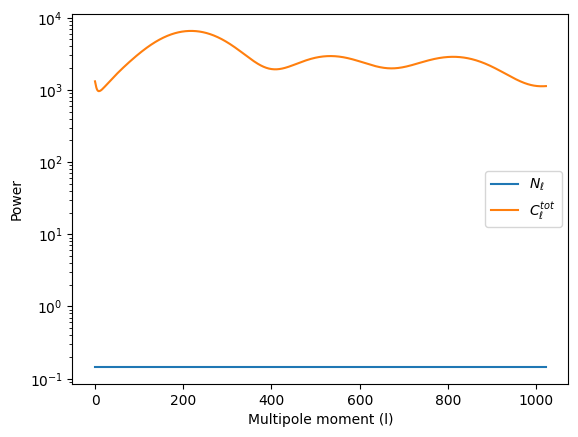

In [167]:
ells = np.arange(2, s.nell)
scale = ells * (ells + 1) / 2 / np.pi
N_ell = s.noise_ell[0, 2:]
C_ell_tot = scale * s.c_ells[2 : s.nell, 0] + N_ell

plt.semilogy(N_ell, label=r"$N_\ell$")
plt.semilogy(C_ell_tot, label=r"$C_{\ell}^{tot}$")
plt.legend()
plt.xlabel("Multipole moment (l)")
plt.ylabel("Power")
plt.show()


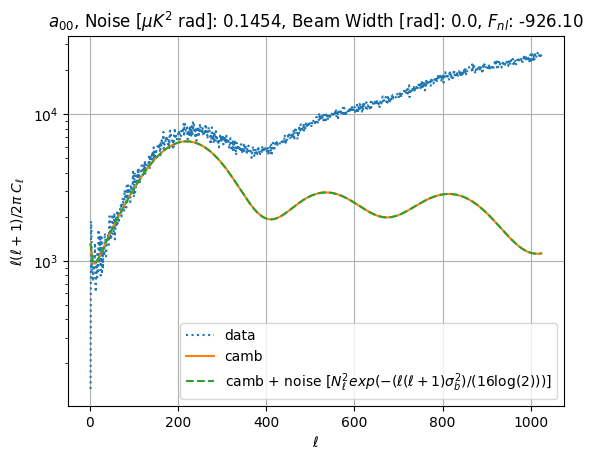

In [176]:
i, j = s.rng.integers(s.nsims), s.rng.integers(s.npol)

plot_cl_alm(
    alms[i, j],
    title=f"$a_{{{i}{j}}}$, Noise [$\\mu K^2$ rad]: {s.noise_scale_tt:.4f}, Beam Width [rad]: {s.beam_width}, $F_{{nl}}$: {fnls[i, j][0]:.2f}",
    plot_camb=True,
    c_ells=s.c_ells,
    camb_noise=True,
    noise=s.noise_ell[0],
    beam_width=s.beam_width,
)


## PatchGen

In [169]:
def cutSqPatches_lenspyx(
    lmax,
    max_l,
    r_dtype,
    npatches,
    nside,
    fs_shape,
    fs_wcs,
    fs_map,
    pshapes,
    pwcs,
    cl_phi,
    alm,
    fnl,
    plot=False,
):
    """Uses lenspyx to generate and cut the lensed flat maps"""
    geom_info = ("healpix", {"nside": nside})

    # Create a full sky map with lenspyx
    plm = lenspyx.utils_hp.synalm(cl_phi, lmax=max_l, mmax=None)
    fl = np.sqrt(np.arange(max_l + 1) * np.arange(1, max_l + 2), dtype=r_dtype)
    dlm = lenspyx.utils_hp.almxfl(
        plm, fl, mmax=None, inplace=False
    )  # inplace breaks, for some reason

    lens_map = lenspyx.alm2lenmap(
        alm.copy(),
        dlm,
        geometry=geom_info,
        nthreads=4,
        epsilon=1e-6,
        pol=False,
    )
    pixell_map = reproject.healpix2map(lens_map, fs_shape, fs_wcs, lmax)

    if plot:
        map2hp = reproject.map2healpix(pixell_map, lmax)
        hp.mollview(map2hp, min=-650.0, max=650, title=f"fnl = {fnl}")
        plt.show()
        plot_cl(hp.anafast(map2hp), lmax)

    patches = []
    for i in range(npatches):
        patch = pixell_map.project(pshapes[i], pwcs[i])
        patches.append(patch)

    return patches


def cutSqPatches_pixell(
    lmax,
    plot_dir,
    base_name,
    npatches,
    c_ells,
    fs_shape,
    fs_wcs,
    fs_map,
    pshapes,
    pwcs,
    alms,
    fnl,
    plot=False,
):
    """Uses pixell to generate and cut the flat sky patches, unlensed"""
    fs_map = enmap.empty(fs_shape, fs_wcs)
    car_map = curvedsky.alm2map(alms, fs_map)

    patches = []
    for i in range(npatches):
        logger.info(f"i {npatches}, {np.shape(pshapes)}, {np.shape(pwcs)}")
        patch = car_map.project(pshapes[i], pwcs[i])  # type: ignore
        patches.append(patch)

    if plot:
        plot_dir = os.path.join(plot_dir, "patchgen")
        os.makedirs(plot_dir, exist_ok=True)

        map2hp = reproject.map2healpix(car_map, lmax)
        hp.mollview(map2hp, min=-650.0, max=650, title=f"fnl = {fnl}")
        plt.savefig(os.path.join(plot_dir, f"{base_name}_{fnl}_fullsky.png"))
        plt.close()

        map_path = os.path.join(plot_dir, f"{base_name}_{fnl}_pixell_cl_map.png")
        plot_cl_map(
            car_map, fs_wcs, lmax, plot_camb=True, c_ells=c_ells, save_file=map_path
        )

        patch_path = os.path.join(plot_dir, f"{base_name}_{fnl}_patch.png")
        plot_patches(np.array(patches), 8, save_file=patch_path)

    return np.array(patches)


def get_fs_patch_geo():
    """Generates the patch geometry using pixell"""
    res = np.deg2rad(s.patch_side_deg / s.nside)
    ps_rad = np.deg2rad(s.patch_side_deg)
    fs_shape, fs_wcs = enmap.fullsky_geometry(res, proj="car")
    fs_map = enmap.empty(fs_shape, fs_wcs)

    patch_shapes = []
    patch_wcss = []
    for counter in np.arange(s.npatches // 2):
        # [[dec_min,ra_min],[dec_max,ra_max]]
        top = [[0, ps_rad * counter], [ps_rad, ps_rad * (counter + 1)]]
        gs, w = enmap.geometry(pos=top, res=res, proj="car")
        patch_shapes.append(gs)
        patch_wcss.append(w)

        bottom = [[-ps_rad, ps_rad * counter], [0, ps_rad * (counter + 1)]]
        gs, w = enmap.geometry(pos=bottom, res=res, proj="car")
        patch_shapes.append(gs)
        patch_wcss.append(w)
    return fs_shape, fs_wcs, fs_map, patch_shapes, patch_wcss


In [170]:
# Here we get the geometry of our patches in a tuple
patch_geo = get_fs_patch_geo()

# we also setup the cutPatches function to use either pixell or lenspyx
# depending on if we are doing lensing or not, and provide a lot of
# arguments that are needed and will stay constant
# we cannot abuse the python scope here since these will need to be pickled
if s.lensing:
    logger.debug("Using lenspyx to generate patches")
    cl_phi = s.cosmo._camb_data.get_lens_potential_cls(
        s.cosmo_params["max_l"], CMB_unit="muK", raw_cl=True
    )[:, 0]

    cutPatches = partial(
        cutSqPatches_lenspyx,
        s.lmax,
        s.cosmo_params["max_l"],
        s.r_dtype,
        s.npatches,
        s.nside,
        *patch_geo,
        cl_phi,
    )
else:
    logger.debug("Using pixell to generate patches")
    cutPatches = partial(
        cutSqPatches_pixell,
        s.lmax,
        s.plot_dir,
        s.base_name,
        s.npatches,
        s.c_ells,
        *patch_geo,
    )

## Start the patch generation
# create the array to store the patches
patches = np.empty(s.patch_shape, dtype=s.r_dtype)

# We use joblib.parallel to generate the patches in parallel
# by default (temp_folder=None) this will use a ram disk /dev/shm
# if the data files are larger than the available memory, about 1TB, it will error
# so we give it a temp folder to use, which wont have that problem
temp_folder = os.environ.get("SCRATCH", None)
logger.debug(f"Using temp folder for patch generation: {temp_folder}")
patch_generator = Parallel(
    n_jobs=1,
    return_as="generator",
    temp_folder=temp_folder,
)(delayed(cutPatches)(alms[i, j], fnls[i, j], True) for i, j in s.sim_pol)

# Get our data from the generator, only update logging every 100 runs, takes a long time
for idx, result in enumerate(
    tqdm(patch_generator, desc="patch progress", total=s.sim_pol_len)
):
    i, pol = s.sim_pol[idx]
    patches[i, pol] = result


17-Apr-24 19:00:56 - __main__ - DEBUG - Using pixell to generate patches

17-Apr-24 19:00:56 - __main__ - DEBUG - Using temp folder for patch generation:                                    
/lustre/scratch/client/users/stevensonb

patch progress:   0%|          | 0/1 [00:00<?, ?it/s]

17-Apr-24 19:00:57 - __main__ - INFO - i 1, (0,), (0,)

╭─────────────────────────────── Traceback (most recent call last) ────────────────────────────────╮
│ in <module>:53                                                                                   │
│                                                                                                  │
│   50 )(delayed(cutPatches)(alms[i, j], fnls[i, j], True) for i, j in s.sim_pol)                  │
│   51                                                                                             │
│   52 # Get our data from the generator, only update logging every 100 runs, takes a long time    │
│ ❱ 53 for idx, result in enumerate(                                                               │
│   54 │   tqdm(patch_generator, desc="patch progress", total=s.sim_pol_len)                       │
│   55 ):                                                                                          │
│   56 │   i, pol = s.sim_pol[idx]                                                                 │
│                                                                                                  │
│ /lustre/work/client/users/stevensonb/.conda/envs/mlpng/lib/python3.11/site-packages/tqdm/noteboo │
│ k.py:254 in __iter__                                                                             │
│                                                                                                  │
│   251 │   def __iter__(self):                                                                    │
│   252 │   │   try:                                                                               │
│   253 │   │   │   it = super(tqdm_notebook, self).__iter__()                                     │
│ ❱ 254 │   │   │   for obj in it:                                                                 │
│   255 │   │   │   │   # return super(tqdm...) will not catch exception                           │
│   256 │   │   │   │   yield obj                                                                  │
│   257 │   │   # NB: except ... [ as ...] breaks IPython async KeyboardInterrupt                  │
│                                                                                                  │
│ /lustre/work/client/users/stevensonb/.conda/envs/mlpng/lib/python3.11/site-packages/tqdm/std.py: │
│ 1178 in __iter__                                                                                 │
│                                                                                                  │
│   1175 │   │   time = self._time                                                                 │
│   1176 │   │                                                                                     │
│   1177 │   │   try:                                                                              │
│ ❱ 1178 │   │   │   for obj in iterable:                                                          │
│   1179 │   │   │   │   yield obj                                                                 │
│   1180 │   │   │   │   # Update and possibly print the progressbar.                              │
│   1181 │   │   │   │   # Note: does not call self.update(1) for speed optimisation.              │
│                                                                                                  │
│ /lustre/work/client/users/stevensonb/.conda/envs/mlpng/lib/python3.11/site-packages/joblib/paral │
│ lel.py:1792 in _get_sequential_output                                                            │
│                                                                                                  │
│   1789 │   │   │   for func, args, kwargs in iterable:                                           │
│   1790 │   │   │   │   self.n_dispatched_batches += 1                                            │
│   1791 │   │   │   │   self.n_dispatched_tasks += 1                                              │
│ ❱ 1792 │   │   │   │   res = func(*args, **kwargs)         

In [ ]:
plot_patches(patches[0, 0], 10)


## Estimator

In [ ]:
mc_file = os.path.join(s.alm_dir, "kswmc", f"{s.base_name}_m.hdf5")
if os.path.exists(mc_file):
    logger.info("Loading KSW state from %s", mc_file)
    s.ksw.start_from_read_state(mc_file)
else:
    raise NotImplementedError(
        f"No MC file, {mc_file}, found. This notebook requires more work"
    )

fisher = float(s.ksw.compute_fisher())
logger.info("Fisher: %s, standard deviation: %s", fisher, np.sqrt(1 / fisher))


def alm_loader(i):
    return alms[i, 0]


idxs = [0]
estimates = s.ksw.compute_estimate_batch(alm_loader, idxs, fisher=fisher)
